## Import Libraries

In [1]:
import os
import cv2
import random
import pandas as pd
import numpy as np
from PIL import Image
from glob import glob
import torch
import ultralytics
from ultralytics import YOLO

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import seaborn as sns

## Visualize Sample Images

In [2]:
def read_labels(label_path):
    with open(label_path, "r") as f:
        lines = f.read().splitlines()

    labels = []
    for line in lines:
        label = [float(n) for n in line.split(" ")]
        label = int(label[0]), label[1:]
        labels.append(label)
    return labels

def generate_class_colors(num_classes):
    random.seed(42)
    return {
        i: (random.uniform(0.5,1), random.uniform(0.5,1), random.uniform(0.5,1))
        for i in range(num_classes)
    }

def visualize_img(index, dataset_img_path, dataset_label_path):
    dataset_img_list = []
    dataset_label_list = []
    if os.path.isdir(dataset_img_path):
        for image_name in os.listdir(dataset_img_path):
            image_path = os.path.join(dataset_img_path, image_name)
            
            if os.path.isfile(image_path):
                dataset_img_list.append(image_path)

    if os.path.isdir(dataset_label_path):
        for label_name in os.listdir(dataset_label_path):
            label_path = os.path.join(dataset_label_path, label_name)
            
            if os.path.isfile(label_path):
                dataset_label_list.append(label_path)
                
    if index >= 0 and index <= len(dataset_img_list) and index <= len(dataset_label_list):
        selected_img = dataset_img_list[index]
        selected_label = dataset_label_list[index]
        print(selected_img)

        img = Image.open(selected_img).convert("RGB")
        labels = read_labels(selected_label)

        class_names = ['aquila', 'bootes', 'canis_major', 'canis_minor', 'cassiopeia', 
                       'cygnus', 'gemini', 'leo', 'lyra', 'moon', 'orion', 'pleiades', 'sagittarius', 'scorpius', 'taurus', 'ursa_major']
        class_colors = generate_class_colors(16)
        img_w, img_h = img.size

        fig, ax = plt.subplots(1, figsize=(10, 5))
        ax.imshow(img)
        
        for label in labels:
            class_id, bbox = label
            cx, cy, w, h = bbox

            cx = img_w * cx
            cy = img_h * cy
            w = img_w * w
            h = img_h * h
        
            hw = w / 2
            hh = h / 2
        
            pt = (cx - hw, cy - hh)

            color = class_colors.get(class_id, "white")
            class_name = class_names[class_id]

            rect = patches.Rectangle(
                pt, w, h, linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                pt[0], pt[1] - 5, class_name, color="white", fontsize=10, 
                bbox=dict(
                    facecolor=color, edgecolor="none", pad=2
                ) 
            )
            
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        return "Image does not exist."

C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\train\images\2022-01-03-00-00-00-n_png_jpg.rf.d385013d9f204b3dbc44fef3971aea13.jpg


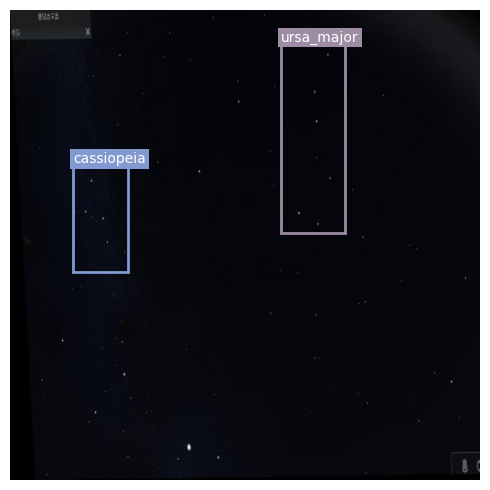

In [5]:
dataset_img_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\train\images"
dataset_label_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\train\labels"

visualize_img(5, dataset_img_path, dataset_label_path)

## YOLO Model

In [2]:
!yolo settings

JSONDict("C:\Users\rafen\AppData\Roaming\Ultralytics\settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "C:\\Users\\rafen\\Documents\\Python Programming (Jupyter Notebook)\\constellations_dataset\\datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "c078706752c9abbd69bc40c86ab39fb58cc3b486180e2761dd2572a1a31b513a",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}
 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [3]:
!yolo checks 



Ultralytics 8.3.236  Python-3.12.12 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Setup complete  (16 CPUs, 15.7 GB RAM, 393.3/474.7 GB disk)

OS                     Windows-11-10.0.26100-SP0
Environment            Windows
Python                 3.12.12
Install                pip
Path                   C:\Users\rafen\anaconda3\envs\gpu-cuda-env\Lib\site-packages\ultralytics
RAM                    15.73 GB
Disk                   393.3/474.7 GB
CPU                    12th Gen Intel Core i5-12500H
CPU count              16
GPU                    NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB
GPU count              1
CUDA                   12.6

numpy                   2.2.6>=1.23.0
matplotlib              3.10.7>=3.3.0
opencv-python           4.12.0.88>=4.6.0
pillow                  12.0.0>=7.1.2
pyyaml                  6.0.3>=5.3.1
requests                2.32.5>=2.23.0
scipy                   1.16.3>=1.4.1
torch                   2.9.1+cu126>=1.8.0
torch         

In [3]:
# Load a model
yolo_11s_model = YOLO("yolo11s.pt")
yolo_11s_model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

### Training YOLOv11s model

In [4]:
yolo_11s_model.train(data = "C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/data.yaml",
                    epochs = 50, imgsz = 640, lr0 = 0.001, batch = 8, optimizer = "AdamW", patience = 5,
                     hsv_s = 0.5, hsv_v = 0.5, flipud = 0.5, fliplr = 0.5)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.236  Python-3.12.12 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001D31C443020>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.04

### Validating YOLOv11s model

In [9]:
yolo_val_model = YOLO("C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/Best Results/detect/train/weights/best.pt")
metrics = yolo_val_model.val(data="C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/data.yaml", 
                             imgsz=640, batch=8, save_json = True, plots = True)

Ultralytics 8.3.236  Python-3.12.12 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLO11s summary (fused): 100 layers, 9,418,992 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 0.60.1 MB/s, size: 12.6 KB)
val: Scanning C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\valid\labels.cache... 469 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 469/469 65.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 5.1it/s 11.7s0.2s
                   all        469       1480       0.93      0.941      0.949       0.59
                aquila         68         68       0.97      0.985      0.981      0.704
                bootes         76         76      0.959          1      0.995      0.681
           canis_major         69         69      0.966      0.986      0.982      0.619
           canis_minor         85         85

### YOLO metrics

Here are some information to know about YOLO metrics:

- AP (Average Precision) - Measures how good the model is at detecting one class by combining precision and recall across all confidences, also the area under the precision-recall curve
- IoU (Intersection over Union) - Calculates the amount of overlapping between two bounding boxes—a predicted bounding box and a ground truth bounding box
- mAP50 - Mean AP across all classes when IoU >= 0.5
- mAP75 - Mean AP across all classes when IoU >= 0.75
- mAP50-95 - Average mAP computed over multiple IoU thresholds (0.50, 0.55, 0.60, …, 0.95) to measure a model's detection ability, localization precision, and robustness across strict criteria

In [10]:
print(metrics.box.map)  # mAP50-95

0.5897508026730464


In [11]:
print(metrics.box.map50)  # mAP50

0.9489737996201778


In [12]:
print(metrics.box.map75)  # mAP75

0.6585800822257405


In [13]:
print(metrics.box.maps)  # list of mAP50-95 for each category

[    0.70389     0.68057     0.61938     0.41593     0.59993     0.73581     0.67866      0.7207     0.48264     0.35844     0.71806     0.16288     0.53021     0.72088     0.60035     0.70768]


### Analyzing the graphs obtained from the model

Here are some information to know:
* Recall - Out of all the real positive cases that exist, how many did the model catch?
* Precision - Out of everything the model predicted as positive, how many are actually positive
* F1 Score - How well does the model balance recall and precision
* Confidence - A filtering score in YOLO that controls how strict the model is about which detections it outputs

Further details about **Confidence** from YOLO:
* Low confidence threshold: The model keeps both strong and weak detections or borderline guesses
* High confidence threshold: The model only keeps the strongest, clearest detections

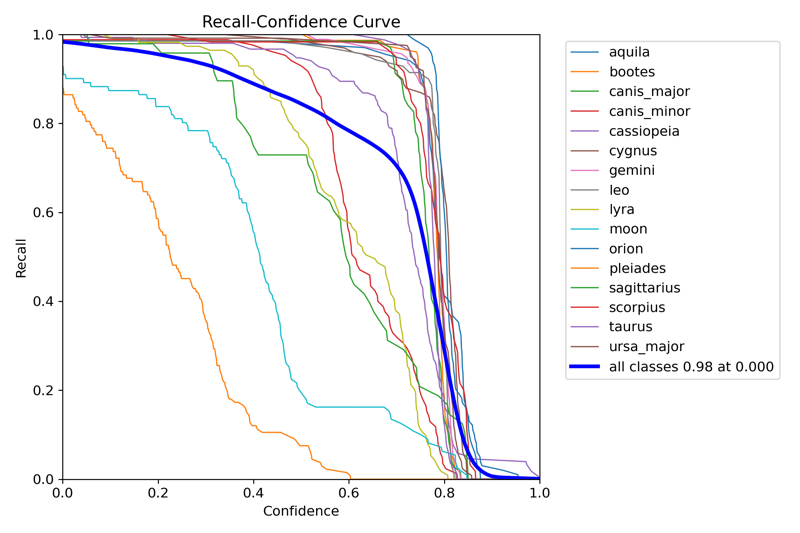

In [3]:
val_recall_conf_img = Image.open(r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\val\BoxR_curve.png")
val_recall_conf_img.thumbnail((800, 800))
val_recall_conf_img

According to the Recall-Confidence Curve graph, we can see that the recall for `Pleiades` and `moon` drops sharply around confidence = 0.3 while others maintain at recall > 0.9. However, the recall for `Pleiades` reaches 0 at confidence = 0.6 while the rest at confidence >= 0.8.

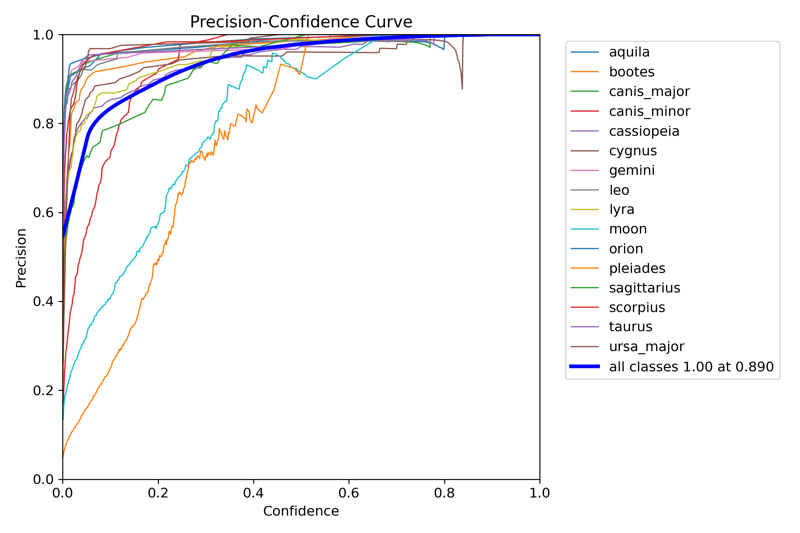

In [14]:
val_precision_conf_img = Image.open(r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\val\BoxP_curve.png")
val_precision_conf_img.thumbnail((800, 800))
val_precision_conf_img

According to the Precision-Confidence Curve graph, we can see that the precision increases rapidly at low confidence and precision > 0.8 at confidence = 0.5 for all classes. The precision for all classes reaches 1.0 at approximately confidence >= 0.85.

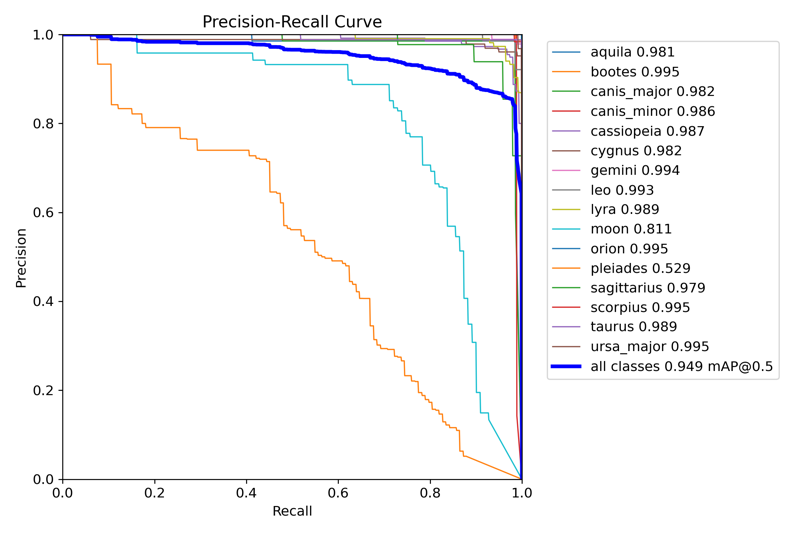

In [15]:
val_precision_recall_img = Image.open(r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\val\BoxPR_curve.png")
val_precision_recall_img.thumbnail((800, 800))
val_precision_recall_img

The Precision-Recall Curve graph is used to tell what precision does the model get at a given recall. In an ideal case, all of the classes should hug the top right region where precision and recall are both high. From the graph below, nearly all cases hug the top right region except for `Pleiades` and `moon` where it shows that the precision collapses at higher recall, the model is detecting more false positive cases.

Area under the curve is AP (Average Precision), we can see that the values for `Pleiades` and `moon` are 0.529 and 0.811 respectively whereas other classes are at least 0.97 and above.

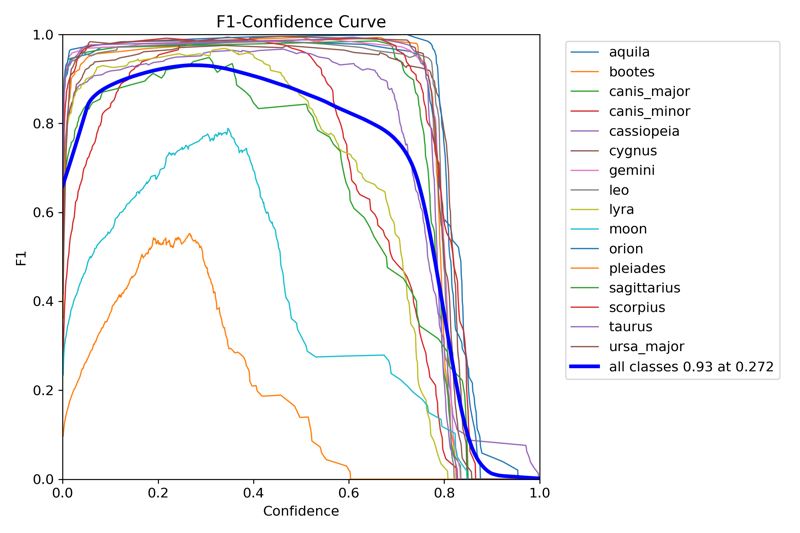

In [5]:
val_f1_conf_img = Image.open(r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\val\BoxF1_curve.png")
val_f1_conf_img.thumbnail((800, 800))
val_f1_conf_img

The F1-Confidence Curve graph shows that at which confidence do precision and recall balance best. In this case, it's shown that at confidence = 0.272, F1-Socre = 0.93 which is the highest.

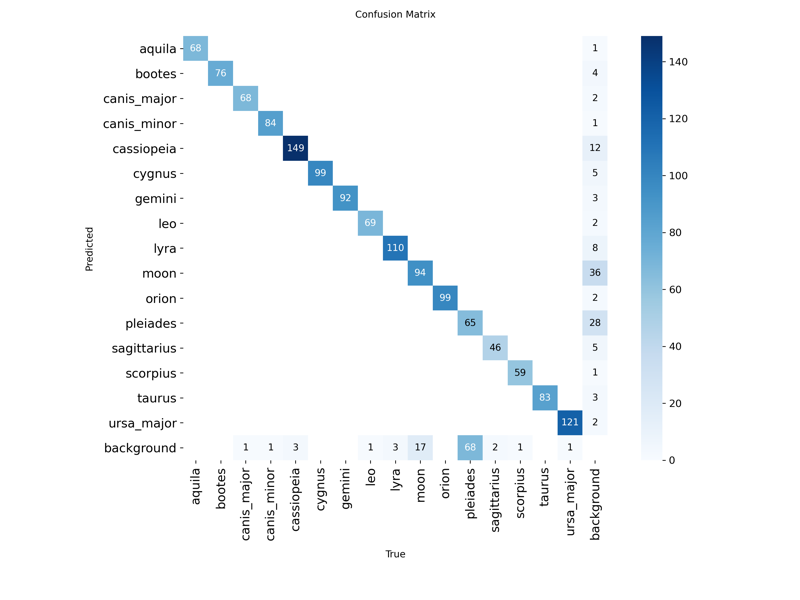

In [7]:
val_cm = Image.open(r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\val\confusion_matrix.png")
val_cm.thumbnail((800, 800))
val_cm

The confusion matrix obtained from validatiing the model on the validation set.

### Testing YOLOv11s model with confidence = 0.4

In [43]:
yolo_pred_model = YOLO("C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/Best Results/detect/train/weights/best.pt")
yolo_pred_model.predict(source="C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/test/images", 
                             conf = 0.4, imgsz=640, batch = 8, save = True, save_txt = True)


image 1/234 C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images\2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f983736111049dfefc1d.jpg: 640x640 1 canis_major, 1 canis_minor, 1 gemini, 1 orion, 1 taurus, 38.5ms
image 2/234 C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images\2022-01-06-00-00-00-n_png_jpg.rf.fa81432a47e707b9a9e242896afc9529.jpg: 640x640 1 cassiopeia, 1 ursa_major, 38.5ms
image 3/234 C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images\2022-01-07-00-00-00-s_png_jpg.rf.97006bcf40d4f4a37307dab3f1a50c1b.jpg: 640x640 1 canis_major, 1 canis_minor, 1 gemini, 1 leo, 1 orion, 1 taurus, 38.5ms
image 4/234 C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images\2022-01-07-00-00-00-s_png_jpg.rf.bb8ec7824b2184ad6d90aca4302c09e3.jpg: 640x640 1 canis_major, 1 canis_minor, 1 gemini, 1 orion, 1 taurus, 38.5ms
ima

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'aquila', 1: 'bootes', 2: 'canis_major', 3: 'canis_minor', 4: 'cassiopeia', 5: 'cygnus', 6: 'gemini', 7: 'leo', 8: 'lyra', 9: 'moon', 10: 'orion', 11: 'pleiades', 12: 'sagittarius', 13: 'scorpius', 14: 'taurus', 15: 'ursa_major'}
 obb: None
 orig_img: array([[[  5,   5,   5],
         [  5,   5,   5],
         [  5,   5,   5],
         ...,
         [ 16,  14,  13],
         [ 13,  11,  10],
         [ 43,  41,  40]],
 
        [[  5,   5,   5],
         [  5,   5,   5],
         [  5,   5,   5],
         ...,
         [ 16,  14,  13],
         [ 15,  13,  12],
         [ 46,  44,  43]],
 
        [[  5,   5,   5],
         [  5,   5,   5],
         [  5,   5,   5],
         ...,
         [ 16,  14,  13],
         [ 16,  14,  13],
         [ 48,  46,  45]],
 
        ...,
 
        [[ 77,  72,  69],
         [193, 188, 185],
         [2

In [3]:
yolo_pred_model = YOLO("C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/lr0 = 0.001, batch = 8 optimizer = AdamW patience = 5 hsv_s = 0.5 hsv_v = 0.5 flipud = 0.5 fliplr = 0.5/detect/train/weights/best.pt")

results = yolo_pred_model("C:/Users/rafen/Documents/Python Programming (Jupyter Notebook)/constellations_dataset/test/images/2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f983736111049dfefc1d.jpg")
results


image 1/1 C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images\2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f983736111049dfefc1d.jpg: 640x640 1 canis_major, 1 canis_minor, 1 gemini, 1 orion, 1 pleiades, 1 taurus, 23.1ms
Speed: 7.1ms preprocess, 23.1ms inference, 15.3ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'aquila', 1: 'bootes', 2: 'canis_major', 3: 'canis_minor', 4: 'cassiopeia', 5: 'cygnus', 6: 'gemini', 7: 'leo', 8: 'lyra', 9: 'moon', 10: 'orion', 11: 'pleiades', 12: 'sagittarius', 13: 'scorpius', 14: 'taurus', 15: 'ursa_major'}
 obb: None
 orig_img: array([[[  5,   5,   5],
         [  5,   5,   5],
         [  5,   5,   5],
         ...,
         [ 16,  14,  13],
         [ 13,  11,  10],
         [ 43,  41,  40]],
 
        [[  5,   5,   5],
         [  5,   5,   5],
         [  5,   5,   5],
         ...,
         [ 16,  14,  13],
         [ 15,  13,  12],
         [ 46,  44,  43]],
 
        [[  5,   5,   5],
         [  5,   5,   5],
         [  5,   5,   5],
         ...,
         [ 16,  14,  13],
         [ 16,  14,  13],
         [ 48,  46,  45]],
 
        ...,
 
        [[ 77,  72,  69],
         [193, 188, 185],
         [2

### Checking test results

In this section, I'll be comparing the actual results with the predicted results to see how many matches, how many constellations are missing or predicted extra from the predicted results. A graph of comparing the actual and predicted count for each constellation is plotted out.

In [44]:
def pred_actual_labels_list(dataset_label_path, class_name):
    dataset_label_list = []
    label_list = []
    
    if os.path.isdir(dataset_label_path):
        for label_name in os.listdir(dataset_label_path):
            label_path = os.path.join(dataset_label_path, label_name)
            
            if os.path.isfile(label_path):
                dataset_label_list.append(label_path)

        for path in dataset_label_list:
            single_label_list = []
            labels = read_labels(path)
            
            for label in labels:
                class_id, bbox = label
                single_label_list.append(class_names[class_id])
            label_list.append(single_label_list)

        return label_list

    else:
        return "Image does not exist."

In [45]:
def image_list(img_path):
    img_name_list = []
    
    if os.path.isdir(img_path):
        for image_name in os.listdir(img_path):
            name_without_ext = os.path.splitext(image_name)[0]
            img_name_list.append(name_without_ext)

    return img_name_list

In [46]:
actual_img_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images"
actual_img_list = image_list(actual_img_path)
actual_img_list

['2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f983736111049dfefc1d',
 '2022-01-06-00-00-00-n_png_jpg.rf.fa81432a47e707b9a9e242896afc9529',
 '2022-01-07-00-00-00-s_png_jpg.rf.97006bcf40d4f4a37307dab3f1a50c1b',
 '2022-01-07-00-00-00-s_png_jpg.rf.bb8ec7824b2184ad6d90aca4302c09e3',
 '2022-01-08-00-00-00-n_png_jpg.rf.9fdef7a3dfb41d1df8ff088ca96315fb',
 '2022-01-09-00-00-00-s_png_jpg.rf.7b7bd1c35be001b49b0d3783effee017',
 '2022-01-11-00-00-00-s_png_jpg.rf.8f45416b744249a5ebd19834d01db4a3',
 '2022-01-16-00-00-00-n_png_jpg.rf.255cd5f27a548318cd8615a7baf256e7',
 '2022-01-16-00-00-00-s_png_jpg.rf.8b9cb3241a25f0de5e7174dbddbc6680',
 '2022-01-17-00-00-00-n_png_jpg.rf.2692cf9e2d580a8ec6f7e2a3ddeffb54',
 '2022-01-19-00-00-00-s_png_jpg.rf.4f48d964f29d30c2c2b3912e0636a9d3',
 '2022-01-20-00-00-00-n_png_jpg.rf.b58be310d4414ff949354dde2b829145',
 '2022-01-21-00-00-00-n_png_jpg.rf.5ced9ae00ef544c14881482cdfabe385',
 '2022-01-21-00-00-00-n_png_jpg.rf.ccccad828db6d2ba68ac3b7b33f4e97b',
 '2022-01-24-00-00-0

In [47]:
pred_img_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\predict\labels"
pred_img_list = image_list(pred_img_path)
pred_img_list

['2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f983736111049dfefc1d',
 '2022-01-06-00-00-00-n_png_jpg.rf.fa81432a47e707b9a9e242896afc9529',
 '2022-01-07-00-00-00-s_png_jpg.rf.97006bcf40d4f4a37307dab3f1a50c1b',
 '2022-01-07-00-00-00-s_png_jpg.rf.bb8ec7824b2184ad6d90aca4302c09e3',
 '2022-01-08-00-00-00-n_png_jpg.rf.9fdef7a3dfb41d1df8ff088ca96315fb',
 '2022-01-09-00-00-00-s_png_jpg.rf.7b7bd1c35be001b49b0d3783effee017',
 '2022-01-11-00-00-00-s_png_jpg.rf.8f45416b744249a5ebd19834d01db4a3',
 '2022-01-16-00-00-00-n_png_jpg.rf.255cd5f27a548318cd8615a7baf256e7',
 '2022-01-16-00-00-00-s_png_jpg.rf.8b9cb3241a25f0de5e7174dbddbc6680',
 '2022-01-17-00-00-00-n_png_jpg.rf.2692cf9e2d580a8ec6f7e2a3ddeffb54',
 '2022-01-19-00-00-00-s_png_jpg.rf.4f48d964f29d30c2c2b3912e0636a9d3',
 '2022-01-20-00-00-00-n_png_jpg.rf.b58be310d4414ff949354dde2b829145',
 '2022-01-21-00-00-00-n_png_jpg.rf.5ced9ae00ef544c14881482cdfabe385',
 '2022-01-21-00-00-00-n_png_jpg.rf.ccccad828db6d2ba68ac3b7b33f4e97b',
 '2022-01-24-00-00-0

In [48]:
missing_img = set(actual_img_list) - set(pred_img_list)
missing_img

{'messier_m45_010_png_jpg.rf.44a4f776c715fedfaf3b04ed24279e7c',
 'messier_m45_010_png_jpg.rf.b4c05dd9727e2e432b824a0fdd7d0032',
 'messier_m45_012_png_jpg.rf.23a9176dde1812d57a0be4870be83429',
 'messier_m45_016_png_jpg.rf.e12e5746e6c8d1e65a62cd21c5226d7a',
 'messier_m45_017_png_jpg.rf.504ce785d82fe2d3cef1d78fb3817050',
 'messier_m45_020_png_jpg.rf.3af19e454a1dd7eb6ebcfaf92095d346',
 'messier_m45_026_png_jpg.rf.d0e15591685f7c78672301211b994165',
 'messier_m45_030_png_jpg.rf.4cee56ebdf69f09416b48e8aa61ed6b5',
 'messier_m45_034_png_jpg.rf.6969a63411be75894782820a8b4cd3a0',
 'messier_m45_034_png_jpg.rf.73e619899f03fc71eb9bcb02ac3375fb',
 'messier_m45_038_png_jpg.rf.b6c86549bdf236a2913797ffecfdb828',
 'messier_m45_041_png_jpg.rf.6038cd54b7d602d4a89217020c910506',
 'messier_m45_046_png_jpg.rf.2c7173ded8539491423f8a2c72a0e879',
 'messier_m45_048_png_jpg.rf.e610642e380ffcebb7c5d1e287778aec',
 'messier_m45_049_png_jpg.rf.0abb34159b31d6de1a29f6331549cc3b'}

In [49]:
class_names = ['aquila', 'bootes', 'canis_major', 'canis_minor', 'cassiopeia', 'cygnus', 
               'gemini', 'leo', 'lyra', 'moon', 'orion', 'pleiades', 'sagittarius', 'scorpius', 'taurus', 'ursa_major']

actual_label_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\labels"
pred_label_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\Best Results\detect\predict\labels"
img_path = r"C:\Users\rafen\Documents\Python Programming (Jupyter Notebook)\constellations_dataset\test\images"

pred_label_list = pred_actual_labels_list(pred_label_path, class_names)
actual_label_list = pred_actual_labels_list(actual_label_path, class_names)

In [50]:
len(actual_label_list), len(pred_label_list), len(actual_img_list)

(234, 219, 234)

In [51]:
pred_map = dict(zip(pred_img_list, pred_label_list))

df = pd.DataFrame({
    "filenames": actual_img_list,
    "actual_results": actual_label_list
})
df["predicted_results"] = df["filenames"].map(pred_map)
df

,filenames,actual_results,predicted_results
0,2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f...,"[orion, pleiades, taurus, canis_major, gemini,...","[gemini, canis_major, orion, taurus, canis_minor]"
1,2022-01-06-00-00-00-n_png_jpg.rf.fa81432a47e70...,"[ursa_major, cassiopeia]","[ursa_major, cassiopeia]"
2,2022-01-07-00-00-00-s_png_jpg.rf.97006bcf40d4f...,"[pleiades, taurus, orion, gemini, canis_major,...","[gemini, orion, canis_major, taurus, canis_min..."
3,2022-01-07-00-00-00-s_png_jpg.rf.bb8ec7824b218...,"[pleiades, taurus, orion, gemini, canis_major,...","[gemini, orion, taurus, canis_major, canis_minor]"
4,2022-01-08-00-00-00-n_png_jpg.rf.9fdef7a3dfb41...,"[ursa_major, cassiopeia]","[ursa_major, cassiopeia]"
...,...,...,...
229,orion_constellation_031_png_jpg.rf.50f16505add...,[orion],[orion]
230,orion_constellation_040_png_jpg.rf.df6c6fac4e3...,[orion],[orion]
231,orion_constellation_043_png_jpg.rf.00830d963a6...,[orion],[orion]
232,orion_constellation_045_png_jpg.rf.a37b5375fc7...,[orion],[orion]


In [52]:
def lists_different(a, b):
    a_set = set(a) if isinstance(a, (list, tuple, set)) else set()
    b_set = set(b) if isinstance(b, (list, tuple, set)) else set()
    return a_set != b_set

In [53]:
df['different'] = df.apply(
    lambda row: lists_different(row['predicted_results'], row['actual_results']),
    axis=1
)
df

,filenames,actual_results,predicted_results,different
0,2022-01-05-00-00-00-s_png_jpg.rf.098ebe8a5c09f...,"[orion, pleiades, taurus, canis_major, gemini,...","[gemini, canis_major, orion, taurus, canis_minor]",True
1,2022-01-06-00-00-00-n_png_jpg.rf.fa81432a47e70...,"[ursa_major, cassiopeia]","[ursa_major, cassiopeia]",False
2,2022-01-07-00-00-00-s_png_jpg.rf.97006bcf40d4f...,"[pleiades, taurus, orion, gemini, canis_major,...","[gemini, orion, canis_major, taurus, canis_min...",True
3,2022-01-07-00-00-00-s_png_jpg.rf.bb8ec7824b218...,"[pleiades, taurus, orion, gemini, canis_major,...","[gemini, orion, taurus, canis_major, canis_minor]",True
4,2022-01-08-00-00-00-n_png_jpg.rf.9fdef7a3dfb41...,"[ursa_major, cassiopeia]","[ursa_major, cassiopeia]",False
...,...,...,...,...
229,orion_constellation_031_png_jpg.rf.50f16505add...,[orion],[orion],False
230,orion_constellation_040_png_jpg.rf.df6c6fac4e3...,[orion],[orion],False
231,orion_constellation_043_png_jpg.rf.00830d963a6...,[orion],[orion],False
232,orion_constellation_045_png_jpg.rf.a37b5375fc7...,[orion],[orion],False


In [55]:
# df.to_excel("constellation_pred_actual_results.xlsx", index=False)

In [56]:
actual_res_exploded = df["actual_results"].explode(ignore_index=True)
actual_res_exploded

0            orion
1         pleiades
2           taurus
3      canis_major
4           gemini
          ...     
709          orion
710          orion
711          orion
712          orion
713          orion
Name: actual_results, Length: 714, dtype: object

In [57]:
actual_res_exploded.value_counts().sort_index()

actual_results
aquila         31
bootes         34
canis_major    33
canis_minor    37
cassiopeia     81
cygnus         54
gemini         40
leo            36
lyra           52
moon           42
orion          49
pleiades       74
sagittarius    20
scorpius       22
taurus         39
ursa_major     69
Name: count, dtype: int64

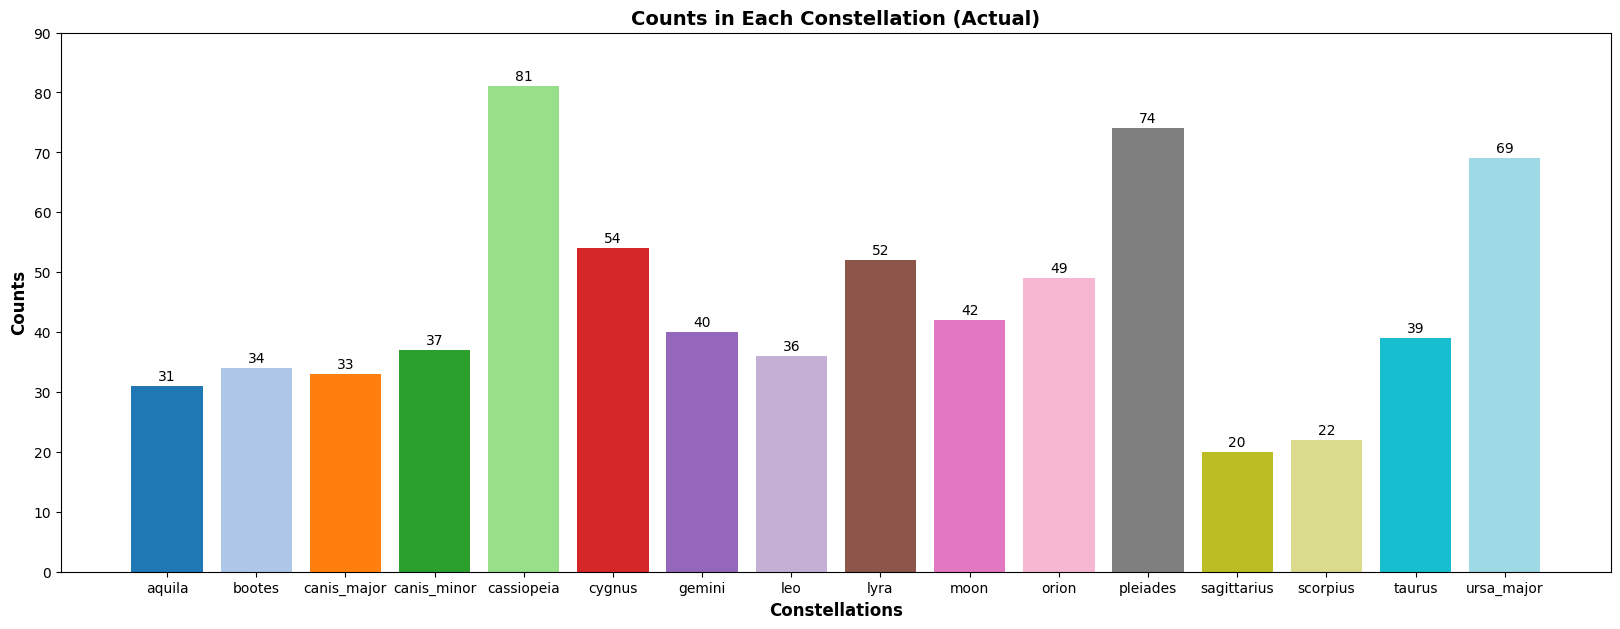

In [58]:
plt.figure(figsize=(20, 7))

colors = cm.tab20(np.linspace(0, 1, len(actual_res_exploded.value_counts())))
bars = plt.bar(actual_res_exploded.value_counts().sort_index().index, actual_res_exploded.value_counts().sort_index().values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height+0.5,
        str(height),
        ha='center',
        va='bottom'
    )

plt.xlabel("Constellations", fontsize=12, fontweight="bold")
plt.ylabel("Counts", fontsize=12, fontweight="bold")
plt.ylim(0, 90)
plt.title("Counts in Each Constellation (Actual)", fontsize=14, fontweight="bold")
plt.show()

In [59]:
pred_res_exploded = df["predicted_results"].explode(ignore_index=True)
pred_res_exploded

0           gemini
1      canis_major
2            orion
3           taurus
4      canis_minor
          ...     
664          orion
665          orion
666          orion
667          orion
668          orion
Name: predicted_results, Length: 669, dtype: object

In [60]:
pred_res_exploded.value_counts().sort_index()

predicted_results
aquila         32
bootes         34
canis_major    33
canis_minor    37
cassiopeia     86
cygnus         57
gemini         41
leo            39
lyra           50
moon           28
orion          48
pleiades       14
sagittarius    19
scorpius       22
taurus         43
ursa_major     71
Name: count, dtype: int64

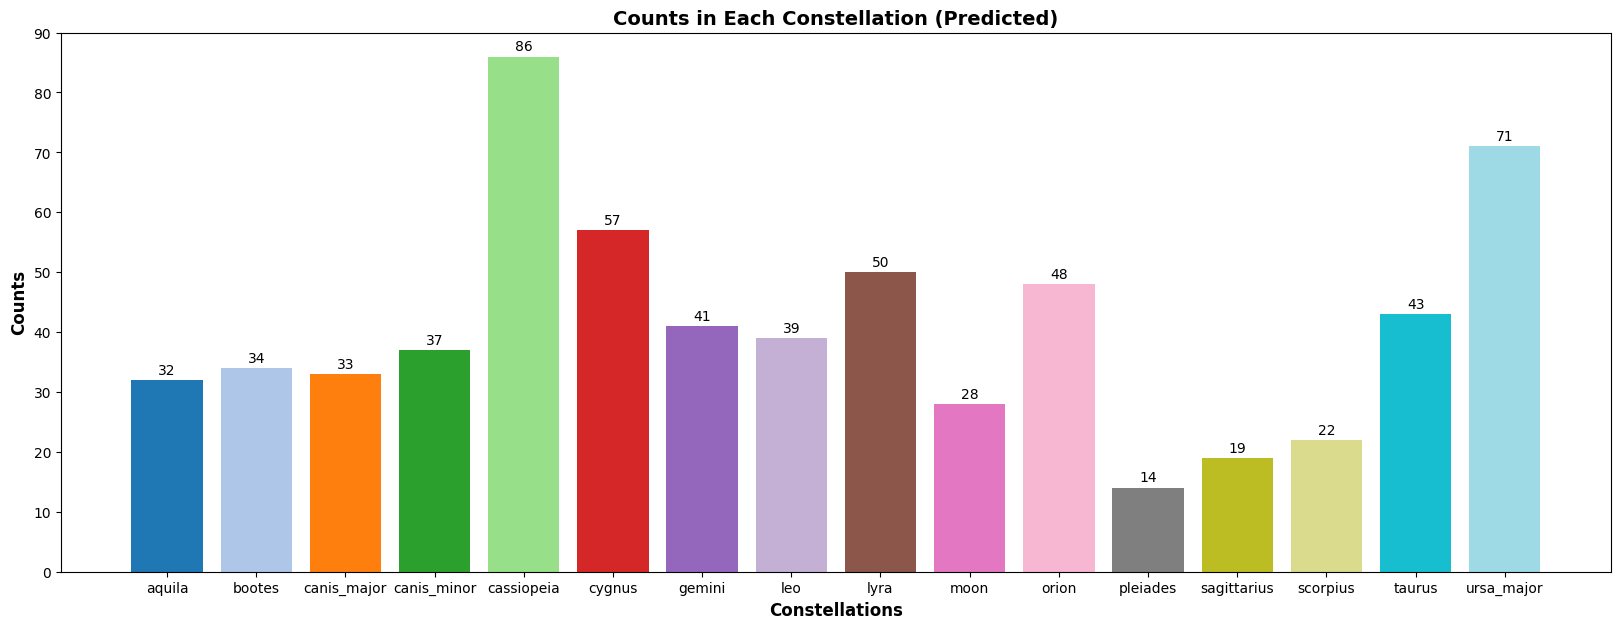

In [61]:
plt.figure(figsize=(20, 7))

colors = cm.tab20(np.linspace(0, 1, len(pred_res_exploded.value_counts())))
bars = plt.bar(pred_res_exploded.value_counts().sort_index().index, pred_res_exploded.value_counts().sort_index().values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height+0.5,
        str(height),
        ha='center',
        va='bottom'
    )

plt.xlabel("Constellations", fontsize=12, fontweight="bold")
plt.ylabel("Counts", fontsize=12, fontweight="bold")
plt.ylim(0, 90)
plt.title("Counts in Each Constellation (Predicted)", fontsize=14, fontweight="bold")
plt.show()

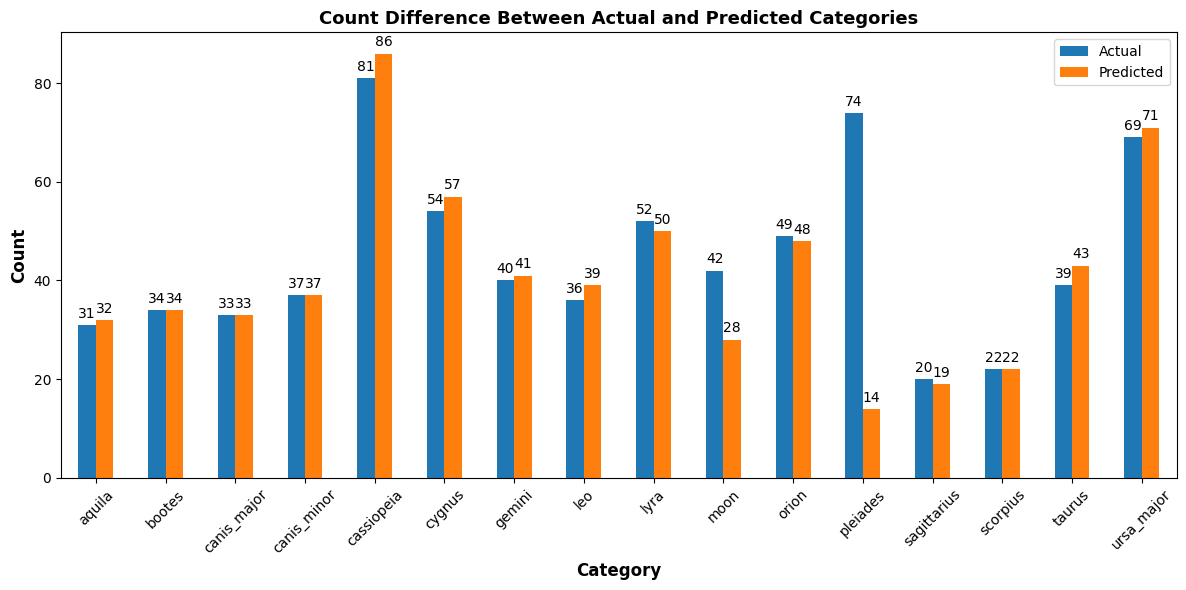

In [62]:
comparison = pd.DataFrame({
    'Actual': actual_res_exploded.value_counts(),
    'Predicted': pred_res_exploded.value_counts()
}).fillna(0)

# Create figure explicitly
fig, ax = plt.subplots(figsize=(12, 6))

comparison.plot(kind='bar', ax=ax)

ax.set_ylabel('Count', fontsize=12, fontweight="bold")
ax.set_xlabel('Category', fontsize=12, fontweight="bold")
ax.set_title('Count Difference Between Actual and Predicted Categories', fontsize=13, fontweight="bold")
ax.tick_params(axis='x', rotation=45)

# Add labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Based on this graph, you can see that `Pleiades` and `moon` have significant differences between their predicted and actual counts, especially `Pleiades` since its mPA50 is the lowest and the model has a difficult time detecting this constellation. Certain constellations have equal counts for their predicted and actual results while others have slight false positive (most notably `cassiopeia`) and false negative detections.